In [1]:
import os
os.chdir(r'C:\Users\Lenovo\Desktop\Diabetes_Classifier\notebooks')
os.chdir("..")
print(os.getcwd())


C:\Users\Lenovo\Desktop\Diabetes_Classifier


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.cluster import KMeans  
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils import shuffle
from src.data_preprocessing import scale,encode
from src.data_feature_engineering import ZScoreFeatures,features
from src.helperFunc import saveFile


In [3]:
df=pd.read_csv("data/clean/Diabetes Classifier Clean.csv")
y=df['diagnosis']
X=df.drop(['diagnosis'],axis=1)

In [4]:
X=encode(X,'gender')
gender=X['gender']
X.drop(['gender'],axis=1)

,age,bmi,chol,tg,hdl,ldl,cr,bun
0,50,24,4.20,0.90,2.40,1.40,46.0,4.70
1,26,23,3.70,1.40,1.10,2.10,62.0,4.50
2,33,21,4.90,1.00,0.80,2.00,46.0,7.10
3,45,21,2.90,1.00,1.00,1.50,24.0,2.30
4,50,24,3.60,1.30,0.90,2.10,50.0,2.00
...,...,...,...,...,...,...,...,...
5127,54,23,5.00,1.50,1.24,2.98,77.0,3.50
5128,50,22,4.37,2.09,1.37,2.29,47.3,4.40
5129,67,24,3.89,1.38,1.14,2.17,70.6,4.73
5130,60,29,5.91,1.29,1.73,2.85,50.2,7.33


Cluster 2         0.239868
cluster_labels    0.227128
Age_x_BMI         0.220167
age               0.186985
BMI/HDL+LDL       0.166760
lipids            0.162810
HDL_x_LDL         0.152896
hdl               0.145848
ldl               0.140985
BMI/LDL           0.139616
Cluster 4         0.123017
chol/ldl          0.114782
bmi               0.112010
Cluster 0         0.108090
Cluster 1         0.106030
Cluster 5         0.098769
tg                0.087776
chol              0.061785
cr                0.044922
Cluster 3         0.040146
bun               0.031886
bun_x_cr          0.026624
gender            0.000000
dtype: float64


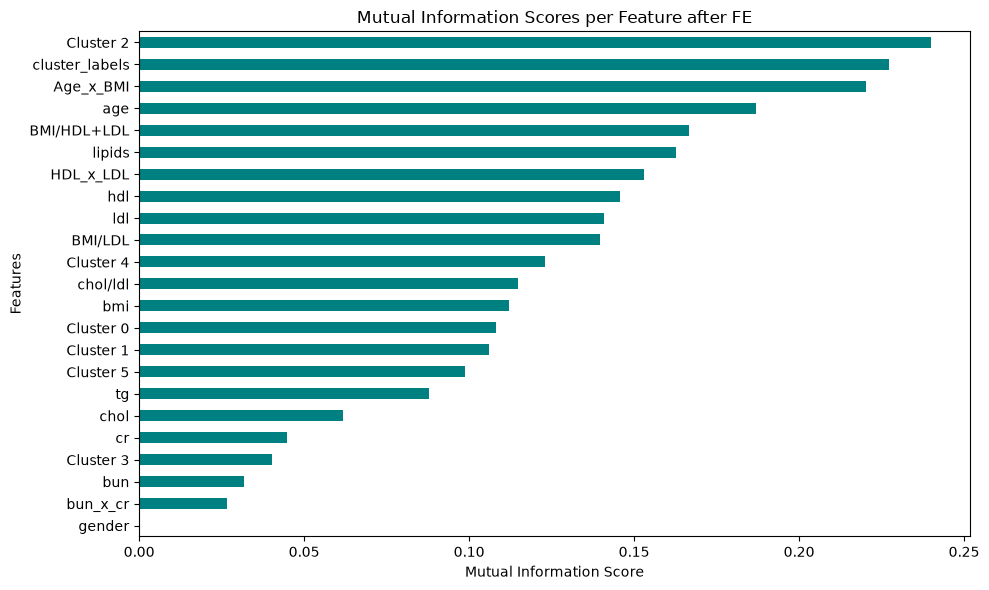

In [ ]:
X=features(X,gender)

feature= X.columns

mi_scores=mutual_info_classif(X,y,random_state=42,n_jobs=-1)

mi_scores_series = pd.Series(mi_scores, index=feature).sort_values(ascending=False)

print(mi_scores_series)     

plt.figure(figsize=(10, 6))
mi_scores_series.plot(kind='barh', color='teal')
plt.title('Mutual Information Scores per Feature after FE')
plt.xlabel('Mutual Information Score')
plt.ylabel('Features')
plt.gca().invert_yaxis() # Top-down display
plt.tight_layout()
plt.show()

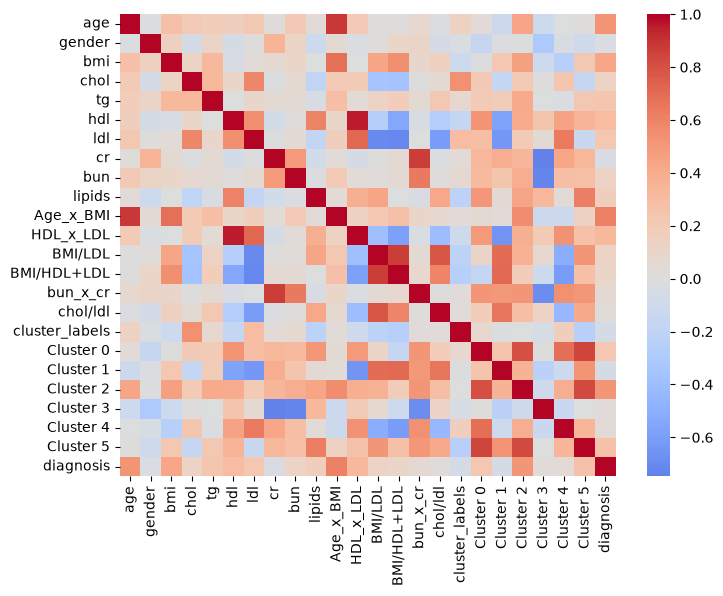

In [6]:


X_sub=pd.concat([X,df['diagnosis']],axis=1)
corr = X_sub.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=False,
            cmap="coolwarm",
            center=0)
plt.show()

In [7]:
df=pd.concat([X,y],axis=1)
pd.set_option('display.max_columns', None)
df = shuffle(df).reset_index(drop=True)
df.columns = df.columns.str.strip()
df.head(10)

PATH="data/preprocessed/Diabetes_Classification_Preprocessed.csv"
saveFile(df,PATH)
